In [289]:
from fears.utils import AutoRate
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from sklearn.linear_model import LinearRegression
import pandas as pd
import pickle
from scipy.optimize import curve_fit

plt.rcParams.update({'font.size': 10, 'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

In [290]:
# create dataframe for background statistics
bg_stats = pd.DataFrame(columns=['species', 'arm', 'blank_mean','blank_SD',
                                 'net_3SD','net_10SD','n'])

# import CFU data
prefix = "../calibration_data/data_08312026/"
cfu_file = prefix + "colony_counts.xlsx"

cfu_data = pd.read_excel(cfu_file, sheet_name='Sheet1')

# change column "Organism" to "species"
cfu_data = cfu_data.rename(columns={"Organism": "species"})
# change column "Range" to "arm"
cfu_data = cfu_data.rename(columns={"Range": "arm"})
# change column "Replicate 1" and "Replicate 2" to "count_1" and "count_2"
cfu_data = cfu_data.rename(columns={"Replicate 1": "count_1", "Replicate 2": "count_2"})
# change column "Column" to "column"
cfu_data = cfu_data.rename(columns={"Column": "column"})

# load e coli upper bound RFU data
rfu_ec_ub_file = prefix + "RFU - E coli - upper bound.xlsx"

p_ab = AutoRate.Plate(rfu_ec_ub_file,mode='single_measurement')
ec_ub_data = p_ab.od_data_to_dict(p_ab.data)

# col 8 is background
rows = ['D','E','F','G']
cols = ['2','3','4','5','6','7','8','9','10']
ec_ub_bg = np.mean([ec_ub_data[r+'11'] for r in rows])

bg_stats_t = pd.DataFrame([{
    'species': 'E. coli',
    'arm': 'Upper bound',
    'blank_mean': ec_ub_bg,
    'blank_SD': np.std([ec_ub_data[r+'11'] for r in rows], ddof=1),
    'net_3SD': 3*np.std([ec_ub_data[r+'11'] for r in rows], ddof=1),
    'net_10SD': 10*np.std([ec_ub_data[r+'11'] for r in rows], ddof=1),
    'n': len([ec_ub_data[r+'11'] for r in rows])
}])
bg_stats = pd.concat([bg_stats, bg_stats_t])

# background subtract
for key in ec_ub_data.keys():
    ec_ub_data[key] -= ec_ub_bg

# get average RFU per column and CV
# ec_ub_avg = {}
# ec_ub_cv = {}
for col in cols:
    values = [ec_ub_data[row+col] for row in rows]
    ec_ub_avg = np.mean(values)
    ec_ub_cv = np.std(values,ddof=1) / np.mean(values)
    ec_ub_std = np.std(values, ddof=1)

    # add to corresponding rows in cfu_data for which species is E. coli, arm is Upper bound, and column matches
    col_int = int(col)
    cfu_data.loc[(cfu_data['species'] == 'E. coli') & (cfu_data['arm'] == 'Upper bound') & (cfu_data['column'] == col_int), 'net_RFU'] = ec_ub_avg
    cfu_data.loc[(cfu_data['species'] == 'E. coli') & (cfu_data['arm'] == 'Upper bound') & (cfu_data['column'] == col_int), 'RFU_CV'] = ec_ub_cv
    cfu_data.loc[(cfu_data['species'] == 'E. coli') & (cfu_data['arm'] == 'Upper bound') & (cfu_data['column'] == col_int), 'RFU_SD'] = ec_ub_std
   
# load s aureus upper bound RFU data
rfu_sa_ub_file = prefix + "RFU - S aureus - upper bound.xlsx"

p_sa = AutoRate.Plate(rfu_sa_ub_file,mode='single_measurement')
sa_ub_data = p_sa.od_data_to_dict(p_sa.data)

# background calculation and subtraction
rows = ['D','E','F','G']
cols = ['2','3','4','5','6','7','8','9','10']
sa_ub_bg = np.mean([sa_ub_data[r+'11'] for r in rows])

bg_stats_t = pd.DataFrame([{
    'species': 'S. aureus',
    'arm': 'Upper bound',
    'blank_mean': sa_ub_bg,
    'blank_SD': np.std([sa_ub_data[r+'11'] for r in rows], ddof=1),
    'net_3SD': 3*np.std([sa_ub_data[r+'11'] for r in rows], ddof=1),
    'net_10SD': 10*np.std([sa_ub_data[r+'11'] for r in rows], ddof=1),
    'n': len([sa_ub_data[r+'11'] for r in rows])
}])
bg_stats = pd.concat([bg_stats, bg_stats_t])



# background subtract
for key in sa_ub_data.keys():
    sa_ub_data[key] -= sa_ub_bg

# get average RFU per column and CV

for col in cols:
    values = [sa_ub_data[row+col] for row in rows]
    sa_ub_avg = np.mean(values)
    sa_ub_cv = np.std(values,ddof=1) / np.mean(values)
    sa_ub_std = np.std(values, ddof=1)

    # add to corresponding rows in cfu_data for which species is S. aureus, arm is Upper bound, and column matches
    col_int = int(col)
    cfu_data.loc[(cfu_data['species'] == 'S. aureus') & (cfu_data['arm'] == 'Upper bound') & (cfu_data['column'] == col_int), 'net_RFU'] = sa_ub_avg
    cfu_data.loc[(cfu_data['species'] == 'S. aureus') & (cfu_data['arm'] == 'Upper bound') & (cfu_data['column'] == col_int), 'RFU_CV'] = sa_ub_cv
    cfu_data.loc[(cfu_data['species'] == 'S. aureus') & (cfu_data['arm'] == 'Upper bound') & (cfu_data['column'] == col_int), 'RFU_SD'] = sa_ub_std


# load lower bound data
rfu_lb_file = prefix + "RFU - E coli and S aureus - lower bound.xlsx"

p_lb = AutoRate.Plate(rfu_lb_file,mode='single_measurement')
lb_data = p_lb.od_data_to_dict(p_lb.data)

# E. coli are in rows B-D, S. aureus are in rows E-G
# background row is 8
sa_lb_rows = ['E','F','G']
ec_lb_rows = ['B','C','D']
cols = ['2','3','4','5','6','7']
ec_lb_bg = np.mean([lb_data[r+'8'] for r in ec_lb_rows])

# background subtract e coli bg from e coli rows
for row in ec_lb_rows:
    for col in cols:
        lb_data[row+col] -= ec_lb_bg

bg_stats_t = pd.DataFrame([{
    'species': 'E. coli',
    'arm': 'Lower bound',
    'blank_mean': ec_lb_bg,
    'blank_SD': np.std([lb_data[r+'8'] for r in ec_lb_rows], ddof=1),
    'net_3SD': 3*np.std([lb_data[r+'8'] for r in ec_lb_rows], ddof=1),
    'net_10SD': 10*np.std([lb_data[r+'8'] for r in ec_lb_rows], ddof=1),
    'n': len([lb_data[r+'8'] for r in ec_lb_rows])
}])
bg_stats = pd.concat([bg_stats, bg_stats_t])

# calculate S. aureus lower bound background
sa_lb_bg = np.mean([lb_data[r+'8'] for r in sa_lb_rows])
bg_stats_t = pd.DataFrame([{
    'species': 'S. aureus',
    'arm': 'Lower bound',
    'blank_mean': sa_lb_bg,
    'blank_SD': np.std([lb_data[r+'8'] for r in sa_lb_rows], ddof=1),
    'net_3SD': 3*np.std([lb_data[r+'8'] for r in sa_lb_rows], ddof=1),
    'net_10SD': 10*np.std([lb_data[r+'8'] for r in sa_lb_rows], ddof=1),
    'n': len([lb_data[r+'8'] for r in sa_lb_rows])
}])
bg_stats = pd.concat([bg_stats, bg_stats_t])

# background subtract for S. aureus
for row in sa_lb_rows:
    for col in cols:
        lb_data[row+col] -= sa_lb_bg

# calculate average RFU per column and CV for lower bound data and add to cfu_data

# E. coli lower bound

for col in cols:
    values = [lb_data[row+col] for row in ec_lb_rows]
    ec_lb_avg = np.mean(values)
    ec_lb_cv = np.std(values,ddof=1) / np.mean(values) if np.mean(values) > 0 else np.nan
    ec_lb_std = np.std(values, ddof=1)

    col_int = int(col)
    cfu_data.loc[(cfu_data['species'] == 'E. coli') & (cfu_data['arm'] == 'Lower bound') & (cfu_data['column'] == col_int), 'net_RFU'] = ec_lb_avg
    cfu_data.loc[(cfu_data['species'] == 'E. coli') & (cfu_data['arm'] == 'Lower bound') & (cfu_data['column'] == col_int), 'RFU_CV'] = ec_lb_cv
    cfu_data.loc[(cfu_data['species'] == 'E. coli') & (cfu_data['arm'] == 'Lower bound') & (cfu_data['column'] == col_int), 'RFU_SD'] = ec_lb_std

# S. aureus lower bound

for col in cols:
    values = [lb_data[row+col] for row in sa_lb_rows]
    sa_lb_avg = np.mean(values)
    sa_lb_cv = np.std(values,ddof=1) / np.mean(values) if np.mean(values) > 0 else np.nan
    sa_lb_std = np.std(values, ddof=1)

    col_int = int(col)
    cfu_data.loc[(cfu_data['species'] == 'S. aureus') & (cfu_data['arm'] == 'Lower bound') & (cfu_data['column'] == col_int), 'net_RFU'] = sa_lb_avg
    cfu_data.loc[(cfu_data['species'] == 'S. aureus') & (cfu_data['arm'] == 'Lower bound') & (cfu_data['column'] == col_int), 'RFU_CV'] = sa_lb_cv
    cfu_data.loc[(cfu_data['species'] == 'S. aureus') & (cfu_data['arm'] == 'Lower bound') & (cfu_data['column'] == col_int), 'RFU_SD'] = sa_lb_std

cfu_data['dilution_factor'] = cfu_data['subsequent_dilution'] / cfu_data['vol']
# for each row in cfu_data, get the number of usable cfu counts
for idx, row in cfu_data.iterrows():
    # count_1 and count_2 between 30 and 300
    count_1 = row['count_1']
    count_2 = row['count_2']
    usable_counts = sum([30 <= count_1 <= 300, 30 <= count_2 <= 300])
    cfu_data.at[idx, 'n_countable'] = usable_counts

    avg = 0
    if 30 <= count_1 <= 300:
        avg += count_1
    if 30 <= count_2 <= 300:
        avg += count_2
    if usable_counts > 0:
        avg /= usable_counts

    if avg == 0:
        avg = np.mean([count_1, count_2])
    cfu_data.at[idx, 'CFU_selected'] = avg * row['dilution_factor']

data = cfu_data.copy()

/var/folders/zc/70qypfn92xg4qzzd0ldt5ks80000gn/T/ipykernel_99391/2469109612.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  bg_stats = pd.concat([bg_stats, bg_stats_t])


In [291]:
data_t

,species,arm,column,count_1,count_2,vol,initial_dilution,subsequent_dilution,expected_colonies,net_RFU,RFU_CV,RFU_SD,dilution_factor,n_countable,CFU_selected,ub_exclude
15,S. aureus,Upper bound,2,4,31,0.10,1,100000,116,8071.00,0.117639,949.463884,1000000.0,1.0,31000000.0,True
17,S. aureus,Upper bound,4,85,107,0.05,4,10000,145,9069.75,0.087357,792.302709,200000.0,2.0,19200000.0,True
18,S. aureus,Upper bound,5,34,65,0.10,8,10000,145,7409.25,0.060788,450.391959,100000.0,2.0,4950000.0,False
19,S. aureus,Upper bound,6,26,99,0.20,16,10000,145,4534.50,0.045252,205.194217,50000.0,1.0,4950000.0,False
20,S. aureus,Upper bound,7,27,40,0.20,32,10000,72,2492.50,0.026802,66.803194,50000.0,1.0,2000000.0,False
21,S. aureus,Upper bound,8,39,205,0.10,64,1000,181,1432.50,0.024562,35.185224,10000.0,2.0,1220000.0,False
23,S. aureus,Upper bound,10,20,38,0.20,256,1000,90,354.25,0.031126,11.026483,5000.0,1.0,190000.0,False


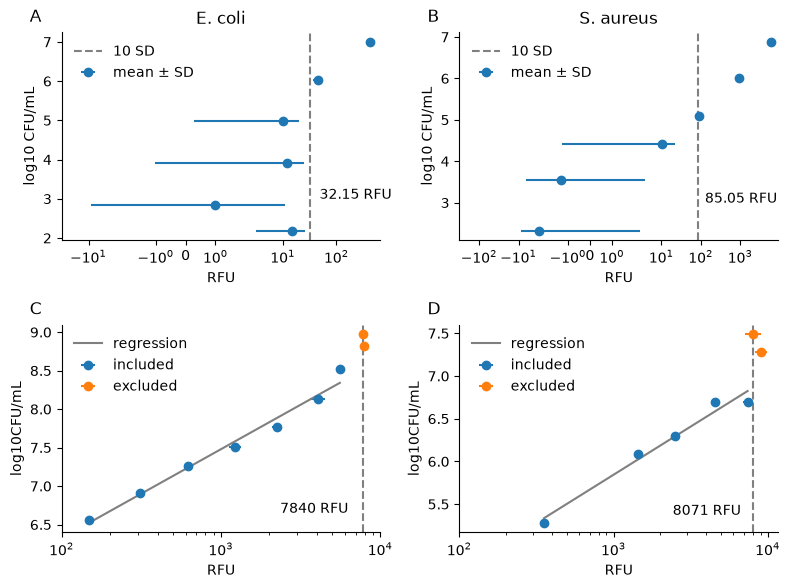

In [ ]:
# for each E. coli and SA low density exp, plot net RFU vs column

fig,ax_list = plt.subplots(ncols=2,nrows=2,figsize=(8,6))

# plot E. coli low density 
ld_cols = ['2','3','4','5','6','7']
ec_ld_avg = []
ec_ld_std = []
data_t = data[(data['species'] == 'E. coli') & (data['arm'] == 'Lower bound')]

# get net RFU as an array
net_RFU = np.array(data_t['net_RFU'])
RFU_std = np.array(data_t['RFU_SD'])
    

# plot E. coli low density
ax = ax_list[0,0]
cfu = np.log10(np.array(data_t['CFU_selected']))
ax.errorbar(net_RFU, cfu, xerr=RFU_std, fmt='o')
ax.set_title('E. coli')
ax.set_xlabel('RFU')
ax.set_ylabel('log10 CFU/mL')
# plot 3 SD and 10 SD lines
bg_sd = bg_stats[(bg_stats['species'] == 'E. coli') & (bg_stats['arm'] == 'Lower bound')]['blank_SD'].values[0]
# ax.axhline(y=3*bg_sd, linestyle=':', label='3 SD',color='gray')
ax.axvline(x=10*bg_sd, linestyle='--', label='10 SD',color='gray')
ax.legend(frameon=False)
ax.set_xscale('symlog')

ax.annotate(np.round(10*bg_sd, 2).astype(str) + ' RFU', 
            xy=(10*bg_sd*1.5, 3), xytext=(10*bg_sd*1.5, 3),fontsize=10)

ax.annotate('A', xy=(-0.1, 1.05), xycoords='axes fraction', fontsize=12)

# increase upper ylim
xl = ax.get_xlim()
ax.set_xlim(xl[0], xl[1]*1.4)

##########################################################################################
# do the same for SA

# plot SA low density
data_t = data[(data['species'] == 'S. aureus') & (data['arm'] == 'Lower bound')]
net_RFU = np.array(data_t['net_RFU'])
RFU_std = np.array(data_t['RFU_SD'])

ax = ax_list[0,1]
cfu = np.log10(np.array(data_t['CFU_selected']))
ax.errorbar(net_RFU, cfu, xerr=RFU_std, fmt='o')

ax.set_title('S. aureus')
ax.set_xlabel('RFU')
ax.set_ylabel('log10 CFU/mL')
bg_sd = bg_stats[(bg_stats['species'] == 'S. aureus') & (bg_stats['arm'] == 'Lower bound')]['blank_SD'].values[0]
# ax.axhline(y=3*bg_sd, linestyle=':', label='3 SD',color='gray')
ax.axvline(x=10*bg_sd, linestyle='--', label='10 SD',color='gray')
ax.legend(frameon=False)
ax.set_xscale('symlog')

# annotate 10*sd 
ax.annotate(np.round(10*bg_sd, 2).astype(str) + ' RFU', 
            xy=(10*bg_sd*1.1, 3), xytext=(10*bg_sd*1.5, 3),fontsize=10)

ax.annotate('B', xy=(-0.1, 1.05), xycoords='axes fraction', fontsize=12)

# increase upper ylim
xl = ax.get_xlim()
ax.set_xlim(xl[0], xl[1]*1.4)

fig.tight_layout()

##########################################################################################

# estimate the expected ratio of RFU between subsequent dilutions using the four most dilute pairs

data_ub = cfu_data[(cfu_data['species'] == 'E. coli') & (cfu_data['arm'] == 'Upper bound')]
data_ub = data_ub.sort_values(by='column')
ratios = []
for i in range(1,len(data_ub)-1):
    ratios.append(data_ub.iloc[i]['net_RFU'] / data_ub.iloc[i-1]['net_RFU'])
expected_ratio = np.mean(ratios)
ratio_std = np.std(ratios)
ratio_ci_lower = expected_ratio - 1.96*ratio_std
ratio_ci_upper = expected_ratio + 1.96*ratio_std

# add column ub_exclude
data_ub['ub_exclude'] = False

# starting from the second column, check if the ratio of RFU to the previous column is within 95% confidence interval
for i in range(1,len(data_ub)-1):
    # get ratio
    ratio = data_ub.iloc[i]['net_RFU'] / data_ub.iloc[i-1]['net_RFU']
    # print(i)
    # include if ratio is within 20% of expected ratio
    if abs(ratio - expected_ratio) / expected_ratio > ratio_ci_lower and abs(ratio - expected_ratio) / expected_ratio < ratio_ci_upper:
        # include this column and the previous one
        data_ub.loc[data_ub.index[i], 'ub_exclude'] = True
        data_ub.loc[data_ub.index[i-1], 'ub_exclude'] = True
    else:
        break

# starting from column 2, exclude consecutive columns with RFU below the expected ratio
# for i in range(1,len(data_ub)-1):
#     # get ratio
#     ratio = data_ub.iloc[i]['net_RFU'] / data_ub.iloc[i-1]['net_RFU']
#     # print(i)
#     # include if ratio is within 20% of expected ratio
#     if abs(ratio - expected_ratio) / expected_ratio > 0.2:
#         # include this column
        
#         data_ub.loc[data_ub.index[i-1], 'ub_exclude'] = True
#     else:
#         break

# plot regression

data_t = data_ub[data_ub['n_countable'] > 0]

include_indx = data_t[~data_t['ub_exclude']].index

# fig,ax_list = plt.subplots(ncols=2, figsize=(8,3))

ax = ax_list[1,0]

ydata = np.log10(data_t.loc[include_indx, 'CFU_selected'])
xdata = data_t.loc[include_indx, 'net_RFU']
xerr = data_t.loc[include_indx, 'RFU_SD']
ax.errorbar(xdata, ydata, label='included', xerr=xerr, fmt='o')
ax.set_xlabel('RFU')
ax.set_ylabel('log10CFU/mL')
# ax[0].set_title('Included Columns')

# fit regression

reg = np.polyfit(np.log10(xdata), ydata, 1)

ydata = np.log10(data_t.loc[~data_t.index.isin(include_indx), 'CFU_selected'])
xerr = data_t.loc[~data_t.index.isin(include_indx), 'RFU_SD']
ax.errorbar(data_t.loc[~data_t.index.isin(include_indx), 'net_RFU'], ydata, label='excluded', xerr=xerr, fmt='o')
ax.plot(xdata, (reg[0]*np.log10(xdata) + reg[1]), color='gray', label='regression')
# ax[0].set_yscale('log')
ax.set_xscale('log')

# shade to the right of the excluded columns

# get the max RFU
max_RFU = np.max(data_t['net_RFU'])

# find the lowest RFU of the excluded columns
# excluded_indx = data_t[data_t['ub_exclude']].index
# lowest_excluded_RFU = data_t.loc[excluded_indx, 'net_RFU'].min()
# ax.axvspan(lowest_excluded_RFU, max_RFU, color='gray', alpha=0.2)

ax.set_xticks([100, 1000, 10000])
ax.legend(frameon=False)

ax.annotate('C', xy=(-0.1, 1.05), xycoords='axes fraction', fontsize=12)

# vertical line indicating the lowest excluded RFU
lowest_excluded_RFU = data_t.loc[data_t['ub_exclude'], 'net_RFU'].min()
ax.axvline(lowest_excluded_RFU, color='gray', linestyle='--')

# annotate with value
ax.annotate(str(int(np.round(lowest_excluded_RFU))) + ' RFU', 
            xy=(lowest_excluded_RFU, ax.get_ylim()[0]), xytext=(lowest_excluded_RFU*0.3, ax.get_ylim()[0]*1.04))

##########################################################################################
# do the same for SA

data_ub = cfu_data[(cfu_data['species'] == 'S. aureus') & (cfu_data['arm'] == 'Upper bound')]

data_ub = data_ub.sort_values(by='column')

ratios = []
for i in range(1,len(data_ub)-1):
    ratios.append(data_ub.iloc[i]['net_RFU'] / data_ub.iloc[i-1]['net_RFU'])
expected_ratio = np.mean(ratios)
ratio_std = np.std(ratios)
ratio_ci_lower = expected_ratio - 1.96*ratio_std
ratio_ci_upper = expected_ratio + 1.96*ratio_std

# add column ub_exclude
data_ub['ub_exclude'] = False

# starting from the second column, check if the ratio of RFU to the previous column is within 95% confidence interval
for i in range(1,len(data_ub)-1):
    # get ratio
    ratio = data_ub.iloc[i]['net_RFU'] / data_ub.iloc[i-1]['net_RFU']
    # print(i)
    # include if ratio is within 20% of expected ratio
    if abs(ratio - expected_ratio) / expected_ratio > ratio_ci_lower and abs(ratio - expected_ratio) / expected_ratio < ratio_ci_upper:
        # include this column and the previous one
        data_ub.loc[data_ub.index[i], 'ub_exclude'] = True
        data_ub.loc[data_ub.index[i-1], 'ub_exclude'] = True
    else:
        break
# starting from column 2, exclude consecutive columns with RFU below the expected ratio
# for i in range(1,len(data_ub)-1):
#     # get ratio
#     ratio = data_ub.iloc[i]['net_RFU'] / data_ub.iloc[i-1]['net_RFU']
#     # include if ratio is within 20% of expected ratio
#     if abs(ratio - expected_ratio) / expected_ratio > 0.2:
#         data_ub.loc[data_ub.index[i-1], 'ub_exclude'] = True
#     else:
#         break

# plot regression

data_t = data_ub[data_ub['n_countable'] > 0]

include_indx = data_t[~data_t['ub_exclude']].index

ax = ax_list[1,1]

ydata = np.log10(data_t.loc[include_indx, 'CFU_selected'])
xdata = data_t.loc[include_indx, 'net_RFU']
xerr = data_t.loc[include_indx, 'RFU_SD']
ax.errorbar(xdata, ydata, label='included', xerr=xerr, fmt='o')
ax.set_xlabel('RFU')
ax.set_ylabel('log10CFU/mL')
# ax[0].set_title('Included Columns')

# fit regression

reg = np.polyfit(np.log10(xdata), ydata, 1)

ydata = np.log10(data_t.loc[~data_t.index.isin(include_indx), 'CFU_selected'])
xerr = data_t.loc[~data_t.index.isin(include_indx), 'RFU_SD']
ax.errorbar(data_t.loc[~data_t.index.isin(include_indx), 'net_RFU'], ydata, label='excluded', xerr=xerr, fmt='o')
ax.plot(xdata, (reg[0]*np.log10(xdata) + reg[1]), color='gray', label='regression')
# ax[0].set_yscale('log')
ax.set_xscale('log')

ax.set_xticks([100, 1000, 10000])
ax.legend(frameon=False)

ax.annotate('D', xy=(-0.1, 1.05), xycoords='axes fraction', fontsize=12)

# vertical line indicating the lowest excluded RFU
lowest_excluded_RFU = data_t.loc[data_t['ub_exclude'], 'net_RFU'].min()
ax.axvline(lowest_excluded_RFU, color='gray', linestyle='--')

# annotate with value
ax.annotate(str(int(np.round(lowest_excluded_RFU))) + ' RFU', 
            xy=(lowest_excluded_RFU, ax.get_ylim()[0]), xytext=(lowest_excluded_RFU*0.3, ax.get_ylim()[0]*1.04))

fig.tight_layout()

fig.savefig('../../figures/calibration_analysis.tiff',dpi=300,bbox_inches='tight')
